# Area conservation by integration step size

`Potential` and `TrajectoryGC` are constructed independently, combined into `System`, and the same square contour is transported with `System.simulate`. A single figure compares the relative area error for `step = 0.01`, `0.005`, and `0.0025`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from classes import GridPotential, SystemResearch, TrajectoryGC, create_system
from config_logging import configure_logging
from workflows.trajectory_initialization import initialize_guiding_center_square
from workflows.potentials import mock_potential

from IPython.display import HTML

configure_logging()

potential: GridPotential = mock_potential(
    A=0.7, M=25, nx=64, ny=64, seed=27, k=5,
)
trajectory = TrajectoryGC(rho=0.3, eta=0.0)

2026-07-19 14:40:57 | INFO     | MainProcess | workflows.potentials | Generating mock potential: A=0.7 M=25 grid=64x64 seed=27 interpolation_order=5
2026-07-19 14:40:57 | INFO     | MainProcess | workflows.potentials | Mock potential ready: modes=1 spatial_period=6.28319


2026-07-19 14:40:57 | INFO     | MainProcess | classes.potential.potential | Plotting potential: mean_field=False, modes=1, quadrature=False, gyroaveraged=False, rho=0
2026-07-19 14:40:57 | INFO     | MainProcess | classes.potential.potential | Plotting fields.modes[0] at omega=-1 as phi(t=0)=2*Re(phi_c).


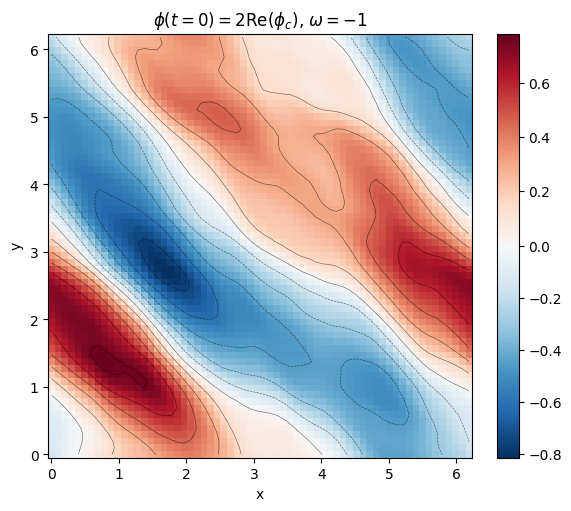

In [2]:
_ = potential.plot()

In [3]:
# As in view_area_conservatios: a 1x1 square with its lower-left vertex
# at the center and 10 points per side.

z0_square = initialize_guiding_center_square(
    trajectory,
    potential.grid,
    side=1.0,
    points_per_side=10,
)
system = create_system(potential, trajectory)
research = SystemResearch(system)

steps = (0.01, 0.005, 0.0025)
t_span = (0.0, 6 * np.pi)
n_output_samples = 361

In [4]:
potential_animation = potential.animate(
    t_max=t_span[1],
    frames=60,
)
HTML(potential_animation.to_jshtml())

2026-07-19 14:40:58 | INFO     | MainProcess | matplotlib.animation | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [5]:
solutions = {}
areas = {}
relative_errors = {}

for integration_step in steps:
    solution = system.simulate(
        step=integration_step,
        t_span=t_span,
        n_output_samples=n_output_samples,
        method='BM4',
        check_energy=False,
        progress=True,
    )
    area = research.guiding_center_polygon_area(solution)
    relative_error = (area - area[0]) / abs(area[0])

    solutions[integration_step] = solution
    areas[integration_step] = area
    relative_errors[integration_step] = relative_error

print(f"{'step':>10} {'n_steps':>12} {'max |relative error|':>20} {'final relative error':>20}")
for integration_step in steps:
    error = relative_errors[integration_step]
    solution = solutions[integration_step]
    print(
        f"{integration_step:10.4g} {solution.n_steps:12d} "
        f"{np.max(np.abs(error)):20.8e} {error[-1]:20.8e}"
    )

solve_extended [==============================] 100.0% (2160/2160 steps, t=18.8496)
solve_extended [==============================] 100.0% (3960/3960 steps, t=18.8496)
solve_extended [==============================] 100.0% (7560/7560 steps, t=18.8496)


      step      n_steps max |relative error| final relative error
      0.01         2160       2.55266193e-02      -3.01327961e-03
     0.005         3960       2.55266193e-02      -3.01327961e-03
    0.0025         7560       2.55266193e-02      -3.01327961e-03


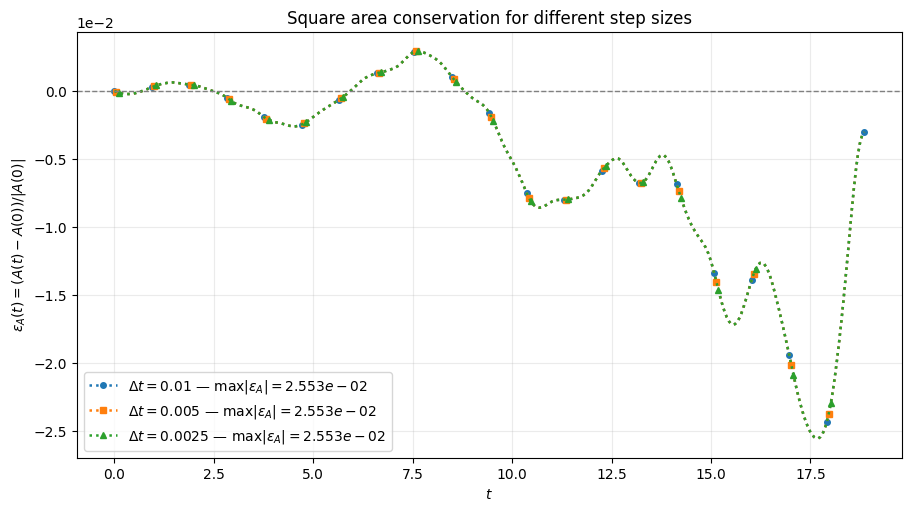

In [6]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

markers = ('o', 's', '^', 'D')
for index, integration_step in enumerate(steps):
    solution = solutions[integration_step]
    error = relative_errors[integration_step]
    max_error = np.max(np.abs(error))
    ax.plot(
        solution.t,
        error,
        label=(
            fr'$\Delta t={integration_step:g}$'
            fr' — $\max|\varepsilon_A|={max_error:.3e}$'
        ),
        ls=':',
        lw=1.8,
        marker=markers[index % len(markers)],
        markevery=(index, max(1, len(solution.t) // 20)),
        markersize=4,
    )

ax.axhline(0.0, color='0.5', ls='--', lw=1)
ax.set(
    xlabel='$t$',
    ylabel=r'$\varepsilon_A(t)=(A(t)-A(0))/|A(0)|$',
    title='Square area conservation for different step sizes',
)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Repeated with 40 points per side

The experiment is repeated with 40 points per side: 160 trajectories in total.

In [7]:
trajectory_160 = TrajectoryGC(rho=0.3, eta=0.0)
z0_square_160 = initialize_guiding_center_square(
    trajectory_160,
    potential.grid,
    side=1.0,
    points_per_side=40,
)
system_160 = create_system(potential, trajectory_160)
research_160 = SystemResearch(system_160)

solutions_160 = {}
relative_errors_160 = {}

for integration_step in steps:
    solution = system_160.simulate(
        step=integration_step,
        t_span=t_span,
        n_output_samples=n_output_samples,
        method='BM4',
        check_energy=False,
        progress=True,
    )
    area = research_160.guiding_center_polygon_area(solution)
    relative_error = (area - area[0]) / abs(area[0])

    solutions_160[integration_step] = solution
    relative_errors_160[integration_step] = relative_error

print(f"{'step':>10} {'n_steps':>12} {'max |relative error|':>20} {'final relative error':>20}")
for integration_step in steps:
    error = relative_errors_160[integration_step]
    solution = solutions_160[integration_step]
    print(
        f"{integration_step:10.4g} {solution.n_steps:12d} "
        f"{np.max(np.abs(error)):20.8e} {error[-1]:20.8e}"
    )

solve_extended [==============================] 100.0% (2160/2160 steps, t=18.8496)
solve_extended [==============================] 100.0% (3960/3960 steps, t=18.8496)
solve_extended [==============================] 100.0% (7560/7560 steps, t=18.8496)


      step      n_steps max |relative error| final relative error
      0.01         2160       1.82579765e-03       5.48680720e-04
     0.005         3960       1.82579765e-03       5.48680719e-04
    0.0025         7560       1.82579765e-03       5.48680717e-04


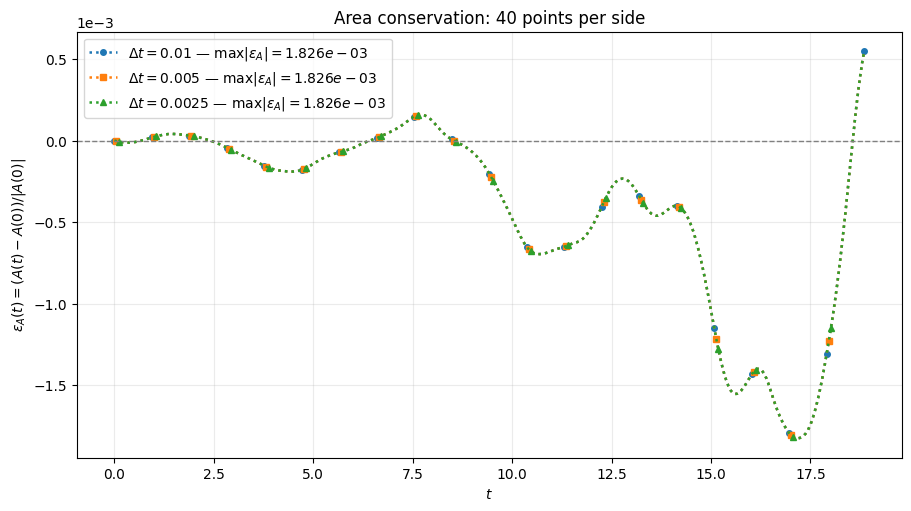

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

markers = ('o', 's', '^', 'D')
for index, integration_step in enumerate(steps):
    solution = solutions_160[integration_step]
    error = relative_errors_160[integration_step]
    max_error = np.max(np.abs(error))
    ax.plot(
        solution.t,
        error,
        label=(
            fr'$\Delta t={integration_step:g}$'
            fr' — $\max|\varepsilon_A|={max_error:.3e}$'
        ),
        ls=':',
        lw=1.8,
        marker=markers[index % len(markers)],
        markevery=(index, max(1, len(solution.t) // 20)),
        markersize=4,
    )

ax.axhline(0.0, color='0.5', ls='--', lw=1)
ax.set(
    xlabel='$t$',
    ylabel=r'$\varepsilon_A(t)=(A(t)-A(0))/|A(0)|$',
    title='Area conservation: 40 points per side',
)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [9]:
potential_animation = potential.animate(
    t_max=t_span[1],
    frames=60,
)
HTML(potential_animation.to_jshtml())

2026-07-19 14:43:29 | INFO     | MainProcess | matplotlib.animation | Animation.save using <class 'matplotlib.animation.HTMLWriter'>
